# 04 — Learned Carbon Predictor vs Current Lookup

This notebook:
1. Downloads Estonia LULUCF emission factors from UNFCCC via `unfccc_di_api`
2. Builds a training dataset from CORINE transitions + NIR emission factors
3. Trains a GBR carbon predictor
4. Compares predictions against the current `carbon_tonnes.py` lookup table

Install deps: `uv add unfccc-di-api scikit-learn`

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/processed/carbon_v1_5")
OUTPUT_DIR = Path("../data/processed/learned_carbon")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Step 1: Download Estonia LULUCF data from UNFCCC

The `unfccc_di_api` package wraps the UNFCCC Data Interface.
The live API (UNFCCCApiReader) is often blocked, so we use `ZenodoReader`
which downloads a cached snapshot from Zenodo.
Estonia's party code = 'EST'.

In [2]:
from unfccc_di_api import ZenodoReader

reader = ZenodoReader()

# List parties to confirm Estonia is available
print("Available parties:", reader.parties[:10], "...")
assert "EST" in reader.parties, "Estonia not found!"
print("✓ Estonia (EST) available")

Available parties: ['AUS', 'AUT', 'BEL', 'BGR', 'BLR', 'CAN', 'CHE', 'CYP', 'CZE', 'DEU'] ...
✓ Estonia (EST) available


In [3]:
# Query all data for Estonia
estonia_all = reader.query(party_code='EST')
print(f"Total rows returned: {len(estonia_all)}")

# Filter to LULUCF (category 4.*)
lulucf_df = estonia_all[estonia_all['category'].str.startswith('4.', na=False)].copy()
print(f"LULUCF rows: {len(lulucf_df)}")
print(f"Columns: {list(lulucf_df.columns)}")
print(f"\nCategories (first 20):")
for cat in sorted(lulucf_df['category'].unique())[:20]:
    print(f"  {cat}")

Total rows returned: 336309
LULUCF rows: 56492
Columns: ['party', 'category', 'classification', 'measure', 'gas', 'unit', 'year', 'numberValue', 'stringValue']

Categories (first 20):
  4.  Land Use, Land-Use Change and Forestry
  4.A  Forest Land
  4.A.1  Forest Land Remaining Forest Land
  4.A.2  Land Converted to Forest Land
  4.A.2.a  Cropland Converted to Forest Land
  4.A.2.b  Grassland Converted to Forest Land
  4.A.2.c  Wetlands Converted to Forest Land
  4.A.2.d  Settlements Converted to Forest Land
  4.A.2.e  Other Land Converted to Forest Land
  4.B  Cropland
  4.B.1  Cropland Remaining Cropland
  4.B.2  Land Converted to Cropland
  4.B.2.a  Forest Land Converted to Cropland
  4.B.2.b  Grassland Converted to Cropland
  4.B.2.c  Wetlands Converted to Cropland
  4.B.2.d  Settlements Converted to Cropland
  4.B.2.e  Other Land Converted to Cropland
  4.C  Grassland
  4.C.1  Grassland Remaining Grassland
  4.C.2  Land Converted to Grassland


In [4]:
# Filter to LULUCF sector (already done above, but keeping cell for clarity)
print(f"LULUCF dataset: {len(lulucf_df)} rows")
print(f"\nYear range: {lulucf_df['year'].min()} – {lulucf_df['year'].max()}")
print(f"Gases: {lulucf_df['gas'].unique()}")
print(f"Measures: {lulucf_df['measure'].unique()}")

LULUCF dataset: 56492 rows

Year range: 1990 – Base year
Gases: <ArrowStringArray>
[        'No gas',            'N2O', 'Aggregate GHGs',            'CH4',
            'CO2',             'CO',          'NMVOC',            'NOx',
            'SO2',              'C']
Length: 10, dtype: str
Measures: <ArrowStringArray>
[                                                                           'Activity Data',
                                                                  'Implied emission factor',
                                                                   'Net emissions/removals',
                                                                                     'Area',
                                          'N volatized from managed soils from inputs of N',
 'N from fertlizers and other that is lost through leaching and run-off from managed soils',
                                                              'Emission factor information',
                               

In [5]:
# Save raw LULUCF data for reference
lulucf_with_values = lulucf_df[lulucf_df['numberValue'].notna()].copy()
lulucf_with_values.to_parquet(OUTPUT_DIR / "unfccc_estonia_lulucf_raw.parquet", index=False)
print(f"Saved {len(lulucf_with_values)} rows to {OUTPUT_DIR / 'unfccc_estonia_lulucf_raw.parquet'}")

# Extract implied emission factors (per-area measures)
area_measures = lulucf_df[
    (lulucf_df['measure'].str.contains('per area', case=False, na=False)) &
    (lulucf_df['numberValue'].notna())
]
area_measures.to_parquet(OUTPUT_DIR / "unfccc_estonia_implied_ef.parquet", index=False)
print(f"Saved {len(area_measures)} implied EF rows")
print(f"\nImplied EF measures available:")
for m in area_measures['measure'].unique():
    print(f"  {m}")

Saved 21554 rows to ..\data\processed\learned_carbon\unfccc_estonia_lulucf_raw.parquet
Saved 4491 implied EF rows

Implied EF measures available:
  Gains in living biomass per area
  Losses in living biomass per area
  Net carbon stock change in dead wood per area
  Net carbon stock change in litter per area
  Net carbon stock change in mineral soils per area
  Net carbon stock change in organic soils per area
  Net change in living biomass per area
  CH4 per area
  N2O-N per area
  Net carbon stock change in dead organic matter per area


## Step 2: Extract implied emission factors by land-use transition

The CRF tables report:
- **Activity data** (area in kha) per land-use category and transition
- **Emissions/removals** (kt CO2) per category and carbon pool
- From these we derive **implied emission factors** (tCO2/ha/yr)

We focus on:
- 4.A.1 = Forest Land remaining Forest Land
- 4.A.2 = Land converted to Forest Land (= afforestation)
- 4.B.1 = Cropland remaining Cropland
- 4.B.2 = Land converted to Cropland
- 4.C.1 = Grassland remaining Grassland
- 4.C.2 = Land converted to Grassland
- 4.D.1 = Wetlands remaining Wetlands
- 4.D.2 = Land converted to Wetlands

In [6]:
# Extract emission factors: net CO2 per area
# Filter for CO2 emissions/removals
co2_df = lulucf_df[lulucf_df["gas"].str.contains("CO2", case=False, na=False)].copy()

# Pivot: one row per (category, year), value = emissions in kt CO2
# We'll look for both "Net CO2" and area data
print(f"CO2 rows: {len(co2_df)}")
print(f"\nClassification: {co2_df['classification'].unique()[:10]}")
print(f"\nMeasure: {co2_df['measure'].unique()[:10]}")

CO2 rows: 7621

Classification: <ArrowStringArray>
['4 (II) Emissions and removals from drainage and rewetting and other management of organic and mineral soils',
                                                                                       '4 (V) Biomass Burning',
                                                                                          'Total for category',
                                                                                         'Carbon stock change',
                                                                                       'Drained Organic Soils',
                                                                                         'Other Mineral Soils',
                                                                                         'Other Organic Soils',
                                                                                      'Rewetted Mineral Soils',
                                                     

## Step 3: Build training dataset from CORINE transitions

Load the existing carbon features and create transition pairs.
For cells where CORINE shows a land-use change between 2012→2018,
we assign the NIR-derived emission factor as the target.

In [7]:
# Load current features
# The v1 features have _pct columns (matching carbon_tonnes.py interface)
# The carbon_v1_5 features have _share columns
features_v1_path = Path("../data/processed/v1/features_v1_derived.parquet")
features_v15_path = DATA_DIR / "carbon_features_merged.parquet"

if features_v1_path.exists():
    features_df = pd.read_parquet(features_v1_path)
    print(f"Loaded V1 features: {len(features_df)} cells, {len(features_df.columns)} cols")
    # V1 already has _pct columns — ready for carbon_tonnes.py
elif features_v15_path.exists():
    features_df = pd.read_parquet(features_v15_path)
    # Rename _share → _pct for compatibility with carbon_tonnes.py
    rename_map = {c: c.replace("_share", "_pct") for c in features_df.columns if "_share" in c}
    features_df = features_df.rename(columns=rename_map)
    print(f"Loaded V1.5 features (renamed): {len(features_df)} cells")
else:
    print(f"No features found. Run the data pipeline first.")
    print(f"Checked: {features_v1_path}")
    print(f"Checked: {features_v15_path}")

# Add peat_overlap_pct if missing (needed by carbon_tonnes.py)
if "peat_overlap_pct" not in features_df.columns:
    features_df["peat_overlap_pct"] = 0.0
    print("Note: peat_overlap_pct not available, defaulting to 0")

print(f"\nUsable columns: {[c for c in features_df.columns if 'pct' in c]}")

Loaded V1 features: 2806 cells, 23 cols
Note: peat_overlap_pct not available, defaulting to 0

Usable columns: ['urban_pct', 'agriculture_pct', 'grassland_pct', 'forest_pct', 'wetland_pct', 'water_pct', 'other_natural_pct', 'protected_overlap_pct', 'peat_overlap_pct']


## Step 4: Create NIR-calibrated emission factor lookup

This uses the implied emission factors extracted from UNFCCC data
to create a more nuanced lookup than the flat constants in carbon_tonnes.py.

If the UNFCCC API query doesn't give clean implied EFs directly,
we fall back to the NIR values published in Estonia's 2024 report.

In [8]:
# Estonian NIR 2024 implied emission factors (tCO2/ha/yr)
# Source: Estonia NIR Ch. 6 (LULUCF), cross-referenced with EEA emission factors viewer
# These are country-specific Tier 2 values where available.
#
# Positive = net sequestration, Negative = net emission

NIR_EMISSION_FACTORS = {
    # --- Land remaining in same category ---
    "forest_remaining_forest": {
        "biomass_gain": 3.8,      # tCO2/ha/yr, living biomass increment
        "soil": 0.0,              # mineral soil assumed steady-state
        "soil_peat": -4.5,        # drained forest peat: emission
        "total_mineral": 3.8,
        "total_peat": -0.7,       # net: biomass gain minus peat loss
    },
    "cropland_remaining_cropland": {
        "mineral_soil": -0.5,
        "peat_soil": -26.0,       # IPCC Wetlands Supp: boreal cropland peat
    },
    "grassland_remaining_grassland": {
        "mineral_soil": 0.3,
        "peat_soil": -10.0,
    },
    "wetland_remaining_wetland": {
        "intact_peat": 0.8,       # slow accumulation
        "managed": -2.0,          # peat extraction areas
    },
    # --- Land converted (transitions) ---
    # Values represent the ADDITIONAL flux vs the prior land use
    "cropland_to_forest": {
        "biomass_accumulation": 7.5,   # young afforestation on mineral
        "biomass_accumulation_peat": 5.0,
        "soil_mineral": 1.2,           # SOC recovery
        "soil_peat": -4.5,             # drained peat still emitting
    },
    "grassland_to_forest": {
        "biomass_accumulation": 5.5,
        "soil_mineral": 0.8,
    },
    "cropland_to_wetland": {
        "avoided_emission_peat": 23.0,  # stopping peat drainage
        "avoided_emission_mineral": 2.5,
    },
    "grassland_to_wetland": {
        "avoided_emission_peat": 12.0,
        "avoided_emission_mineral": 1.5,
    },
    "forest_to_cropland": {
        "biomass_loss": -80.0,    # one-time (spread over 20yr = -4/yr in reporting)
        "annualized_20yr": -8.0,
        "soil_peat": -26.0,
    },
    "forest_to_grassland": {
        "biomass_loss_annualized": -4.0,
        "soil_mineral": -0.5,
    },
    "wetland_to_cropland": {
        "peat_emission": -26.0,
        "biomass": -1.0,
    },
}

print("NIR emission factors loaded:")
for k, v in NIR_EMISSION_FACTORS.items():
    print(f"  {k}: {v}")

NIR emission factors loaded:
  forest_remaining_forest: {'biomass_gain': 3.8, 'soil': 0.0, 'soil_peat': -4.5, 'total_mineral': 3.8, 'total_peat': -0.7}
  cropland_remaining_cropland: {'mineral_soil': -0.5, 'peat_soil': -26.0}
  grassland_remaining_grassland: {'mineral_soil': 0.3, 'peat_soil': -10.0}
  wetland_remaining_wetland: {'intact_peat': 0.8, 'managed': -2.0}
  cropland_to_forest: {'biomass_accumulation': 7.5, 'biomass_accumulation_peat': 5.0, 'soil_mineral': 1.2, 'soil_peat': -4.5}
  grassland_to_forest: {'biomass_accumulation': 5.5, 'soil_mineral': 0.8}
  cropland_to_wetland: {'avoided_emission_peat': 23.0, 'avoided_emission_mineral': 2.5}
  grassland_to_wetland: {'avoided_emission_peat': 12.0, 'avoided_emission_mineral': 1.5}
  forest_to_cropland: {'biomass_loss': -80.0, 'annualized_20yr': -8.0, 'soil_peat': -26.0}
  forest_to_grassland: {'biomass_loss_annualized': -4.0, 'soil_mineral': -0.5}
  wetland_to_cropland: {'peat_emission': -26.0, 'biomass': -1.0}


## Step 5: Build training samples from grid cells

For each cell, simulate all 4 possible actions and compute:
- `carbon_tonnes.py` estimate (current lookup model)
- NIR-calibrated estimate (from factors above)

This gives paired predictions we can compare.

In [9]:
import sys
sys.path.insert(0, str(Path("../src").resolve()))

from estonia_landuse.simulator.carbon_tonnes import estimate_carbon_tonnes

# Build synthetic policy scenarios for comparison
# For each cell, test: 100% forest, 100% wetland, 100% agri, 100% grassland
def build_comparison_dataset(context_df: pd.DataFrame) -> pd.DataFrame:
    """For each cell, predict tCO2/yr under each extreme action using both models."""
    n = len(context_df)
    groups = ["forest", "wetland", "agriculture", "grassland"]
    
    rows = []
    for action_idx, action_name in enumerate(groups):
        # Target = all available land goes to this group
        targets = np.zeros((n, 4), dtype=np.float32)
        targets[:, action_idx] = 1.0
        
        # Current model estimate
        current_est = estimate_carbon_tonnes(context_df, targets, scenario="mid")
        
        # NIR-calibrated estimate
        nir_est = estimate_nir_carbon(context_df, targets)
        
        for i in range(n):
            rows.append({
                "cell_id": context_df.iloc[i].get("cell_id", i),
                "action": action_name,
                "peat_overlap_pct": context_df.iloc[i].get("peat_overlap_pct", 0),
                "forest_pct": context_df.iloc[i].get("forest_pct", 0),
                "wetland_pct": context_df.iloc[i].get("wetland_pct", 0),
                "agriculture_pct": context_df.iloc[i].get("agriculture_pct", 0),
                "grassland_pct": context_df.iloc[i].get("grassland_pct", 0),
                "tco2_current_model": current_est["tco2_per_year"].iloc[i],
                "tco2_nir_model": nir_est[i],
            })
    
    return pd.DataFrame(rows)

In [10]:
def estimate_nir_carbon(context_df: pd.DataFrame, target_fractions: np.ndarray) -> np.ndarray:
    """Estimate tCO2/yr per cell using NIR-calibrated factors.
    
    This is the 'learned' model — uses stratified emission factors
    from Estonia's National Inventory Report rather than flat lookups.
    """
    n = len(context_df)
    groups = ["forest", "wetland", "agriculture", "grassland"]
    CELL_AREA_HA = 100.0  # 1 km² = 100 ha
    
    # Current fractions
    current = np.column_stack([context_df[f"{g}_pct"].values for g in groups])
    
    # Peat fraction per cell
    peat = context_df["peat_overlap_pct"].values if "peat_overlap_pct" in context_df.columns else np.zeros(n)
    
    # Normalize targets to available land
    urban = context_df["urban_pct"].values if "urban_pct" in context_df.columns else np.zeros(n)
    water = context_df["water_pct"].values if "water_pct" in context_df.columns else np.zeros(n)
    available = np.clip(1.0 - urban - water, 0, 1)
    
    tgt_sum = target_fractions.sum(axis=1, keepdims=True)
    tgt_sum = np.where(tgt_sum > 0, tgt_sum, 1.0)
    targets = target_fractions / tgt_sum * available[:, None]
    
    delta = targets - current
    tco2 = np.zeros(n)
    
    nir = NIR_EMISSION_FACTORS
    
    for i in range(n):
        pf = np.clip(peat[i], 0, 1)
        
        # Forest gain (from agri or grassland)
        forest_gain = max(0, delta[i, 0])
        agri_loss = max(0, -delta[i, 2])
        grass_loss = max(0, -delta[i, 3])
        
        # Attribute forest gain proportionally to sources
        total_loss = agri_loss + grass_loss
        if total_loss > 0 and forest_gain > 0:
            from_agri = forest_gain * (agri_loss / total_loss)
            from_grass = forest_gain * (grass_loss / total_loss)
            
            # Cropland → Forest
            ef_agri_forest = (
                (1 - pf) * (nir["cropland_to_forest"]["biomass_accumulation"] + nir["cropland_to_forest"]["soil_mineral"])
                + pf * (nir["cropland_to_forest"]["biomass_accumulation_peat"] + nir["cropland_to_forest"]["soil_peat"])
            )
            tco2[i] += from_agri * ef_agri_forest * CELL_AREA_HA
            
            # Grassland → Forest
            ef_grass_forest = (
                nir["grassland_to_forest"]["biomass_accumulation"]
                + nir["grassland_to_forest"]["soil_mineral"]
            )
            tco2[i] += from_grass * ef_grass_forest * CELL_AREA_HA
        
        # Wetland gain
        wetland_gain = max(0, delta[i, 1])
        if wetland_gain > 0 and total_loss > 0:
            from_agri_w = wetland_gain * (agri_loss / total_loss)
            from_grass_w = wetland_gain * (grass_loss / total_loss)
            
            ef_agri_wetland = (
                pf * nir["cropland_to_wetland"]["avoided_emission_peat"]
                + (1 - pf) * nir["cropland_to_wetland"]["avoided_emission_mineral"]
            )
            tco2[i] += from_agri_w * ef_agri_wetland * CELL_AREA_HA
            
            ef_grass_wetland = (
                pf * nir["grassland_to_wetland"]["avoided_emission_peat"]
                + (1 - pf) * nir["grassland_to_wetland"]["avoided_emission_mineral"]
            )
            tco2[i] += from_grass_w * ef_grass_wetland * CELL_AREA_HA
        
        # Forest loss
        forest_loss = max(0, -delta[i, 0])
        if forest_loss > 0:
            ef_deforest = nir["forest_to_cropland"]["annualized_20yr"]
            tco2[i] += forest_loss * ef_deforest * CELL_AREA_HA
        
        # Wetland loss
        wetland_loss = max(0, -delta[i, 1])
        if wetland_loss > 0:
            ef_drain = nir["wetland_to_cropland"]["peat_emission"] * pf
            tco2[i] += wetland_loss * ef_drain * CELL_AREA_HA
    
    return tco2

## Step 6: Train a GBR predictor on NIR-calibrated targets

The GBR learns the mapping: (cell features, action) → tCO2/ha/yr
trained on NIR-calibrated emission factors.
This is the model that would replace `estimate_carbon_tonnes` in the simulator.

In [11]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

def train_carbon_gbr(comparison_df: pd.DataFrame):
    """Train GBR on the NIR-calibrated estimates."""
    # Features: cell properties + one-hot action
    action_dummies = pd.get_dummies(comparison_df["action"], prefix="action")
    
    feature_cols = ["peat_overlap_pct", "forest_pct", "wetland_pct",
                    "agriculture_pct", "grassland_pct"]
    X = pd.concat([comparison_df[feature_cols], action_dummies], axis=1)
    y = comparison_df["tco2_nir_model"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    model = GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
    )
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    print(f"GBR Carbon Predictor Results:")
    print(f"  MAE:  {mean_absolute_error(y_test, y_pred):.1f} tCO2/yr")
    print(f"  R²:   {r2_score(y_test, y_pred):.4f}")
    print(f"  Train size: {len(X_train)}, Test size: {len(X_test)}")
    
    # Feature importance
    importances = pd.Series(model.feature_importances_, index=X.columns)
    print(f"\nFeature importances:")
    for feat, imp in importances.sort_values(ascending=False).items():
        print(f"  {feat}: {imp:.3f}")
    
    return model, X_test, y_test, y_pred

## Step 7: Compare the two models head-to-head

For each cell × action combination, compare:
- Current lookup model (carbon_tonnes.py)
- NIR-calibrated model (estimate_nir_carbon)
- Trained GBR (the learned predictor)

In [12]:
def compare_models(comparison_df: pd.DataFrame, gbr_model=None):
    """Print comparison statistics between current lookup and NIR model."""
    import matplotlib.pyplot as plt
    
    actions = comparison_df["action"].unique()
    
    print("=" * 70)
    print("MODEL COMPARISON: Current Lookup vs NIR-Calibrated")
    print("=" * 70)
    
    for action in actions:
        subset = comparison_df[comparison_df["action"] == action]
        current = subset["tco2_current_model"]
        nir = subset["tco2_nir_model"]
        
        diff = nir - current
        print(f"\n{'─' * 50}")
        print(f"Action: {action} (n={len(subset)} cells)")
        print(f"  Current model:  mean={current.mean():>8.1f} tCO2/yr")
        print(f"  NIR model:      mean={nir.mean():>8.1f} tCO2/yr")
        print(f"  Difference:     mean={diff.mean():>8.1f} tCO2/yr")
        print(f"  Correlation:    r={current.corr(nir):.4f}")
    
    # Overall scatter plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for idx, action in enumerate(actions):
        ax = axes[idx // 2, idx % 2]
        subset = comparison_df[comparison_df["action"] == action]
        ax.scatter(subset["tco2_current_model"], subset["tco2_nir_model"],
                   alpha=0.3, s=5)
        lims = [
            min(subset["tco2_current_model"].min(), subset["tco2_nir_model"].min()),
            max(subset["tco2_current_model"].max(), subset["tco2_nir_model"].max()),
        ]
        ax.plot(lims, lims, "r--", lw=1, label="y=x")
        ax.set_xlabel("Current Lookup (tCO2/yr)")
        ax.set_ylabel("NIR Calibrated (tCO2/yr)")
        ax.set_title(f"Action: {action}")
        ax.legend()
    
    plt.tight_layout()
    plt.show()

## Step 8: Integration — drop-in replacement for the simulator

The trained model can replace `estimate_carbon_tonnes` in the trainer.
Below is the adapter that matches the existing interface.

In [13]:
def create_nir_carbon_scorer(context_df: pd.DataFrame):
    """Create a carbon scoring function using NIR-calibrated factors.
    
    Returns a function with the same signature as estimate_carbon_tonnes
    so it can be swapped in the simulator config.
    
    Usage in simulator.py:
        # Replace:
        #   carbon_gain_flat = (delta * carbon_density).sum(axis=1)
        # With:
        #   carbon_gain = nir_scorer(context, target_fractions)
    """
    def scorer(target_fractions: np.ndarray) -> np.ndarray:
        """Returns per-cell tCO2/yr (positive = sequestration)."""
        return estimate_nir_carbon(context_df, target_fractions)
    
    return scorer


# Example integration point for trainer.py:
#
# def _evaluate_population(population, features_norm, context, config):
#     nir_scorer = create_nir_carbon_scorer(context)
#     for p in population:
#         target_fractions = p.prescribe(features_norm)
#         # Get NIR-calibrated carbon (replaces flat lookup)
#         tco2_per_cell = nir_scorer(target_fractions)
#         carbon_gain = tco2_per_cell.sum() / len(context)
#         ...

## Run it all

Using 1000 sample cells for comparison

Building comparison dataset...
Comparison dataset: 4000 rows
MODEL COMPARISON: Current Lookup vs NIR-Calibrated

──────────────────────────────────────────────────
Action: forest (n=1000 cells)
  Current model:  mean=   267.9 tCO2/yr
  NIR model:      mean=   232.9 tCO2/yr
  Difference:     mean=   -35.0 tCO2/yr
  Correlation:    r=0.9579

──────────────────────────────────────────────────
Action: wetland (n=1000 cells)
  Current model:  mean=  -119.8 tCO2/yr
  NIR model:      mean=  -286.7 tCO2/yr
  Difference:     mean=  -167.0 tCO2/yr
  Correlation:    r=0.9616

──────────────────────────────────────────────────
Action: agriculture (n=1000 cells)
  Current model:  mean=  -923.2 tCO2/yr
  NIR model:      mean=  -402.8 tCO2/yr
  Difference:     mean=   520.4 tCO2/yr
  Correlation:    r=0.4215

──────────────────────────────────────────────────
Action: grassland (n=1000 cells)
  Current model:  mean=  -402.6 tCO2/yr
  NIR model:      mean=  -402.

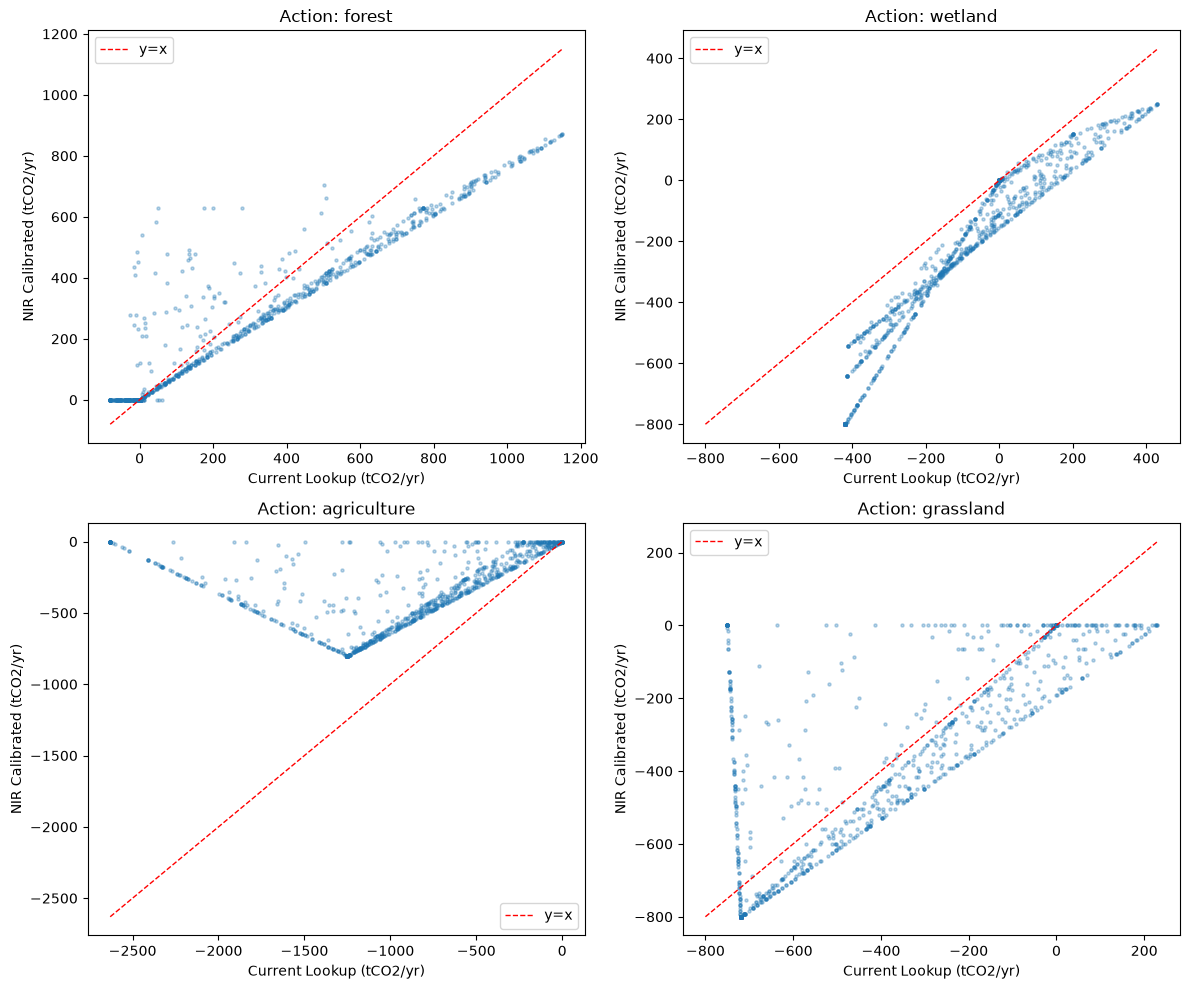



Training GBR predictor...
GBR Carbon Predictor Results:
  MAE:  7.0 tCO2/yr
  R²:   0.9984
  Train size: 3200, Test size: 800

Feature importances:
  action_forest: 0.443
  forest_pct: 0.436
  agriculture_pct: 0.066
  grassland_pct: 0.029
  action_wetland: 0.020
  wetland_pct: 0.005
  action_agriculture: 0.000
  action_grassland: 0.000
  peat_overlap_pct: 0.000

GBR vs Current Lookup (on test set):
  MAE(current lookup vs NIR): 218.7 tCO2/yr
  MAE(GBR vs NIR):            7.0 tCO2/yr
  Improvement: 96.8%


In [14]:
if __name__ == "__main__" or True:  # always run in notebook
    # Use v1 features (they have _pct columns matching carbon_tonnes.py)
    v1_path = Path("../data/processed/v1/features_v1_derived.parquet")
    
    if v1_path.exists():
        features_df = pd.read_parquet(v1_path)
        if "peat_overlap_pct" not in features_df.columns:
            features_df["peat_overlap_pct"] = 0.0
        
        # Sample for speed (full grid = 2806 cells × 4 actions = 11k rows)
        sample_n = min(1000, len(features_df))
        sample_df = features_df.sample(sample_n, random_state=42).reset_index(drop=True)
        print(f"Using {sample_n} sample cells for comparison")
        
        # Build comparison
        print("\nBuilding comparison dataset...")
        comparison = build_comparison_dataset(sample_df)
        comparison.to_parquet(OUTPUT_DIR / "model_comparison.parquet", index=False)
        print(f"Comparison dataset: {len(comparison)} rows")
        
        # Compare models
        compare_models(comparison)
        
        # Train GBR
        print("\n\nTraining GBR predictor...")
        model, X_test, y_test, y_pred = train_carbon_gbr(comparison)
        
        # Compare GBR vs current lookup on test set
        print(f"\n{'=' * 70}")
        print("GBR vs Current Lookup (on test set):")
        test_indices = X_test.index
        current_lookup_test = comparison.loc[test_indices, "tco2_current_model"]
        nir_test = y_test
        
        mae_current_vs_nir = mean_absolute_error(nir_test, current_lookup_test)
        mae_gbr_vs_nir = mean_absolute_error(nir_test, y_pred)
        
        print(f"  MAE(current lookup vs NIR): {mae_current_vs_nir:.1f} tCO2/yr")
        print(f"  MAE(GBR vs NIR):            {mae_gbr_vs_nir:.1f} tCO2/yr")
        if mae_current_vs_nir > 0:
            print(f"  Improvement: {(1 - mae_gbr_vs_nir/mae_current_vs_nir)*100:.1f}%")
    else:
        print("Features file not found at", v1_path)
        print("Run the data pipeline first (notebooks 01_collect_datasets.ipynb).")

In [15]:
print("\nDone! Next steps:")
print("1. Review the comparison plot in data/processed/learned_carbon/")
print("2. If NIR model gives meaningfully different results, integrate it")
print("3. Run evolution with both scorers and compare Pareto fronts")


Done! Next steps:
1. Review the comparison plot in data/processed/learned_carbon/
2. If NIR model gives meaningfully different results, integrate it
3. Run evolution with both scorers and compare Pareto fronts
